# Descriptive Answers

Questions and their resulting answers from our exploration of our data, along with visuals and mathematical evidence.

## Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import os
import glob


# set style for Seaborn
colour_palette = ["#42698E", "#FF8552", "#7C9FC1", "#D6E5F1", "#C0D4E7", "#211A1D"]
sns.set_theme(style="whitegrid", palette=colour_palette, font="Segoe UI", font_scale=1.1)

## Functions

In [2]:
### functions ###
    
def combine_csv_in_folder(data_folder: str, output_file: str="transactions.csv") -> None:
    """
    
    Combine the all the CSVs in data_folder into a single CSV.
    Assuming all the CSVs being combined have the same format.
    
    Adapted from code by: Ishfaq
    
    Input:
        data_folder (str): Name of the folder with all the CSVs.
        output_file (str): Name of the CSV of all the CSVs.
        
    Returns:
        None
        
    """
    # get a list of all CSVs in the data_folder
    all_files = glob.glob(os.path.join(data_folder, "**", "*.csv"), recursive=True)
    print(f"Found {len(all_files)} CSV files.\n")

    # iterate through each CSV, read the CSV, add a column with the demographic group name (folder name)
    dfs = []
    for fp in sorted(all_files):
        print("Loading:", fp)
        df = pd.read_csv(fp)
        folder = os.path.basename(os.path.dirname(fp))   # e.g. cleaned_50up_f_r
        area_type = folder[-1]
        if area_type == "r":
            df["area_type"] = "rural"
        elif area_type == "u":
            df["area_type"] = "urban"
        dfs.append(df)
    
    # combine all the DataFrames into a single one
    data = pd.concat(dfs, ignore_index=True)
    
    # save the combined data DataFrame as a CSV
    data.to_csv(output_file, index=False)
    print(f"CSV files combined and saved to {output_file}.")

## Load Data

In [3]:
# paths
DATA_ROOT = "cleaned_data_files"
combined_data_path = "transactions.csv"

# check if combined data CSV alreday exists and if not make it
if not os.path.isfile(combined_data_path):
    combine_csv_in_folder(DATA_ROOT, combined_data_path)

In [4]:
# load data
df = pd.read_csv(combined_data_path)

In [5]:
# view the first few rows
display(df.head())

# get shape of data
print(f"Data Shape: {df.shape}\n")

# check for missing values
print(f"Number of Missing Values per Feature:\n{df.isnull().sum()}\n")

# get column data types
print("Feature Data Info:")
df.info()

# get descriptive stats for numeric columns
print(f"\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

,cc_num,gender,city,state,zip,lat,long,city_pop,job,category,amt,is_fraud,merchant,merch_lat,merch_long,trans_datetime,age,area_type
0,2331599965047738,F,Ashton,MD,20861,39.1510,-76.9924,1875,Neurosurgeon,gas_transport,76.49,0,"Lind, Huel and McClure",40.138571,-77.284546,2019-01-01 01:03:49,37,rural
1,4438983640376137917,F,Quentin,PA,17083,40.2764,-76.4112,109,Broadcast journalist,gas_transport,6.96,0,"Stroman, Hudson and Erdman",39.631906,-76.851074,2019-01-01 01:15:25,41,rural
2,2331599965047738,F,Ashton,MD,20861,39.1510,-76.9924,1875,Neurosurgeon,gas_transport,80.91,0,"Raynor, Feest and Miller",39.719848,-77.528245,2019-01-01 01:19:08,37,rural
3,213160930685388,F,Bloomingrose,WV,25024,38.1412,-81.6367,586,Midwife,gas_transport,98.28,0,Bernhard Inc,38.637231,-81.161895,2019-01-01 01:21:43,30,rural
4,4438983640376137917,F,Quentin,PA,17083,40.2764,-76.4112,109,Broadcast journalist,gas_transport,50.02,0,Bernhard Inc,39.621815,-77.149117,2019-01-01 03:01:13,41,rural


Data Shape: (3478813, 18)

Number of Missing Values per Feature:
cc_num            0
gender            0
city              0
state             0
zip               0
lat               0
long              0
city_pop          0
job               0
category          0
amt               0
is_fraud          0
merchant          0
merch_lat         0
merch_long        0
trans_datetime    0
age               0
area_type         0
dtype: int64

Feature Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3478813 entries, 0 to 3478812
Data columns (total 18 columns):
 #   Column          Dtype  
---  ------          -----  
 0   cc_num          int64  
 1   gender          object 
 2   city            object 
 3   state           object 
 4   zip             int64  
 5   lat             float64
 6   long            float64
 7   city_pop        int64  
 8   job             object 
 9   category        object 
 10  amt             float64
 11  is_fraud        int64  
 12  merchant        ob

,cc_num,zip,lat,long,city_pop,amt,is_fraud,merch_lat,merch_long,age
count,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06
mean,3.829977e+17,5.141218e+04,3.747681e+01,-9.187338e+01,2.848557e+05,7.116761e+01,5.470544e-03,3.747696e+01,-9.187331e+01,3.883391e+01
std,1.254155e+18,2.979604e+04,5.065531e+00,1.611235e+01,5.479204e+05,1.680841e+02,7.376055e-02,5.097963e+00,1.612256e+01,1.770211e+01
min,6.040027e+10,1.027000e+03,1.955060e+01,-1.580174e+02,7.600000e+01,1.000000e+00,0.000000e+00,1.855116e+01,-1.588502e+02,8.000000e+00
25%,1.800754e+14,2.752900e+04,3.388420e+01,-9.811620e+01,1.786300e+04,9.130000e+00,0.000000e+00,3.387108e+01,-9.820568e+01,2.500000e+01
50%,3.522170e+15,4.811100e+04,3.831750e+01,-8.735260e+01,6.000200e+04,4.456000e+01,0.000000e+00,3.819555e+01,-8.723914e+01,3.700000e+01
75%,4.676428e+15,7.823900e+04,4.112570e+01,-7.995280e+01,2.222720e+05,8.210000e+01,0.000000e+00,4.118815e+01,-7.976854e+01,5.000000e+01
max,4.989104e+18,9.958600e+04,6.266820e+01,-6.726410e+01,2.906700e+06,5.294123e+04,1.000000e+00,6.366737e+01,-6.626601e+01,9.000000e+01


In [6]:
# check fraud distribution
fraud_counts = df["is_fraud"].value_counts()
print(f"Fraud Transaction Counts: {fraud_counts} \n")

fraud_rate = df['is_fraud'].mean()
print("Fraud Rate:", fraud_rate)

Fraud Transaction Counts: is_fraud
0    3459782
1      19031
Name: count, dtype: int64 

Fraud Rate: 0.00547054411950283


## Descriptive Question 1

**Question**: Do fraudulent transactions have higher amounts?

**Feature**: `amt` (numeric)

**Test**: t-test

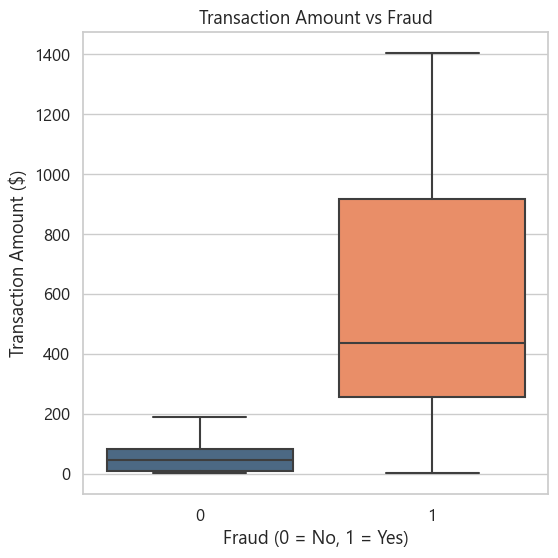

In [7]:
# visual inspection
plt.figure(figsize=(6, 6))

sns.boxplot(x="is_fraud", y="amt", data=df, showfliers=False)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount ($)")

plt.show()

In [8]:
# mathematical interpretation
fraud_amt = df[df["is_fraud"] == 1]["amt"]
nonfraud_amt = df[df["is_fraud"] == 0]["amt"]

# hypotheses
print("**Hypothesis Test for Transaction Amount vs Fraud**\n")
print("Null Hypothesis (H_0): The mean transaction amount is the same for fraudulent and non-fraudulent transactions.")
print("Alternative Hypothesis (H_A): The mean transaction amount for fraudulent transactions is greater than that for non-fraudulent transactions.\n")

# get means
print(f"Mean Amount for Fraud: ${fraud_amt.mean():.2f}")
print(f"Mean Amount for Non-Fraud: ${nonfraud_amt.mean():.2f}")

# two sample t-test assuming unequal variance
t_stat, p_value_two_sided = stats.ttest_ind(fraud_amt, nonfraud_amt, equal_var=False)
p_value_one_sided = p_value_two_sided / 2
print(f"\nt-statistic: {t_stat:.4f}")
print(f"One-sided p-value: {p_value_one_sided:.6f}")

# Cohen's d because large sample size
pooled_sd = np.sqrt(((fraud_amt.var() + nonfraud_amt.var()) / 2))
cohen_d = (fraud_amt.mean() - nonfraud_amt.mean()) / pooled_sd
print(f"Cohen's d: {cohen_d:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value_one_sided < alpha and t_stat > 0:
    print(f"\nSince p-value ({p_value_one_sided:.6f}) < {alpha}, reject the null hypothesis.")
    print("The fraudulent transaction amounts are statistically significantly larger than non-fraudulent transactions.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= {alpha}, we fail to reject the null hypothesis.")
    
print(f"Cohen's d of {cohen_d:.4f} indicates a large effect size, meaning the difference in transaction amounts is substantial and has practical significance.")

**Hypothesis Test for Transaction Amount vs Fraud**

Null Hypothesis (H_0): The mean transaction amount is the same for fraudulent and non-fraudulent transactions.
Alternative Hypothesis (H_A): The mean transaction amount for fraudulent transactions is greater than that for non-fraudulent transactions.

Mean Amount for Fraud: $537.9840617939151
Mean Amount for Non-Fraud: $68.59981885852922

t-statistic: 164.3480
One-sided p-value: 0.000000
Cohen's d: 1.5584
Alpha: 0.01

Since p-value (0.000000) < 0.01, reject the null hypothesis.
The fraudulent transaction amounts are statistically significantly larger than non-fraudulent transactions.
Cohen's d of 1.5584 indicates a large effect size, meaning the difference in transaction amounts is substantial and has practical significance.


**Answer**: Fraudulent transactions have significantly higher transaction amounts than non-fraudulent transactions. The t-test showed a very large difference in mean transaction amounts (mean for fraud: \\$537.98 vs non-fraud: \\$68.60) with a t-statistic of 164.35, a p-value < 0.000001, and a large effect size (Cohen’s d = 1.5584).

## Descriptive Question 2

**Question**: Does fraud vary by category?

**Feature**: `category` (catgeorical)

**Test**: Chi-square

In [9]:
# get fraud rate per category
category_stats = df.groupby("category")["is_fraud"].agg(["mean", "count"])
category_stats = category_stats.rename(columns={"mean": "fraud_rate","count": "transactions"})

# print stats
print(category_stats.sort_values("fraud_rate", ascending=False))

# reset index and sort for plotting later
plot_category_stats = category_stats.reset_index()
plot_category_stats = plot_category_stats.sort_values("fraud_rate", ascending=False)

                fraud_rate  transactions
category                                
shopping_net      0.017384        256150
misc_net          0.015194        158877
grocery_pos       0.013518        327273
shopping_pos      0.006601        343572
gas_transport     0.005150        298459
travel            0.002868        110537
misc_pos          0.002566        228337
entertainment     0.002230        252905
personal_care     0.002044        246123
grocery_net       0.001925        148536
food_dining       0.001714        261338
health_fitness    0.001616        217196
kids_pets         0.001449        302965
home              0.001351        326545


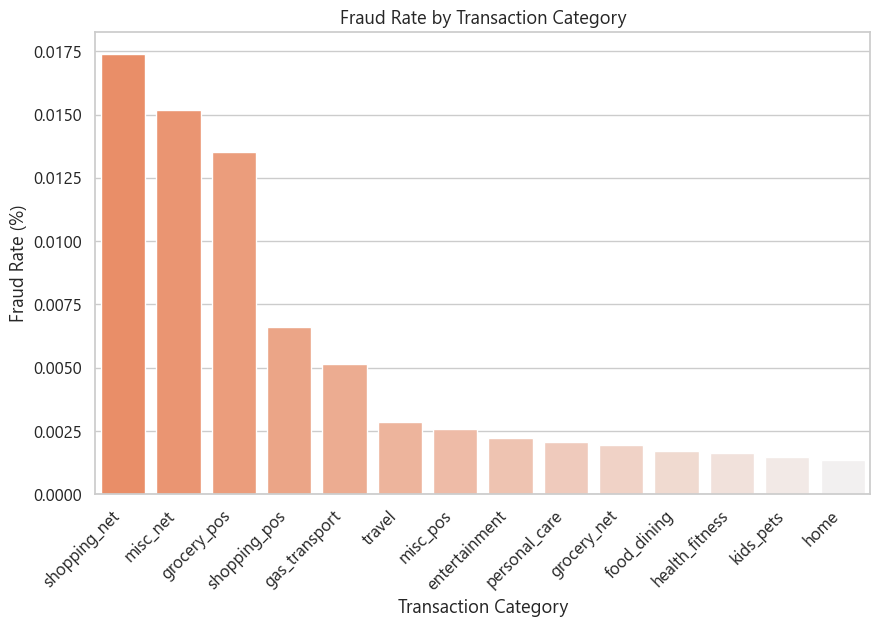

In [10]:
# visual inspection
plt.figure(figsize=(10, 6))
fraud_palette = sns.light_palette("#FF8552", n_colors=len(plot_category_stats), reverse=True)

sns.barplot(x="category", y="fraud_rate", data=plot_category_stats, palette=fraud_palette)
plt.xticks(rotation=45, ha="right")
plt.title("Fraud Rate by Transaction Category")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Transaction Category")

plt.show()

In [11]:
# mathematical interpretation
fraud_category_table = pd.crosstab(df["category"], df["is_fraud"])

# hypotheses
print("**Hypothesis Test for Transaction Category vs Fraud**\n")
print("Null Hypothesis (H_0): Fraudulent transactions are independent of transaction category.")
print("Alternative Hypothesis (H_A): Fraudulent transactions depend on transaction category.\n")

print("Fraud Rate by Category:")
print(category_stats)

# chi-sqaure test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(fraud_category_table)
p_value_one_sided = p_value_two_sided / 2
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

# Cramer's V because of large sample size
n = fraud_category_table.sum().sum() 
min_dim = min(fraud_category_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"Cramer's V: {cramers_v:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value < alpha:
    print(f"\nSince p-value ({p_value:.6f}) < {alpha}, reject the null hypothesis.")
    print("There is statistical evidence that fraud transactions depend on transaction category.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= {alpha}, we fail to reject the null hypothesis.")

print(f"Cramer's V  of {cramers_v:.4f} indicates a weak association between fraud and transaction category, meaning fraud is slightly more likely in certain categories, but the association is not very strong.")

**Hypothesis Test for Transaction Category vs Fraud**

Null Hypothesis (H_0): Fraudulent transactions are independent of transaction category.
Alternative Hypothesis (H_A): Fraudulent transactions depend on transaction category.

Fraud Rate by Category:
                fraud_rate  transactions
category                                
entertainment     0.002230        252905
food_dining       0.001714        261338
gas_transport     0.005150        298459
grocery_net       0.001925        148536
grocery_pos       0.013518        327273
health_fitness    0.001616        217196
home              0.001351        326545
kids_pets         0.001449        302965
misc_net          0.015194        158877
misc_pos          0.002566        228337
personal_care     0.002044        246123
shopping_net      0.017384        256150
shopping_pos      0.006601        343572
travel            0.002868        110537

Chi-square statistic: 18469.7768
Degrees of freedom: 13
p-value: 0.000000
Cramer's V: 0.0

**Answer**: Fraudulent transactions vary significantly across different transaction categories. The chi-square test showed a strong association between fraud and category (p-value < 0.000001), but the effect size (Cramer's V = 0.0729) indicates that while the relationship is statistically significant, it is weak.

## Descriptive Question 3

**Question**: Is age related to fraud?

**Feature**: `age` (numeric)

**Test**: t-test

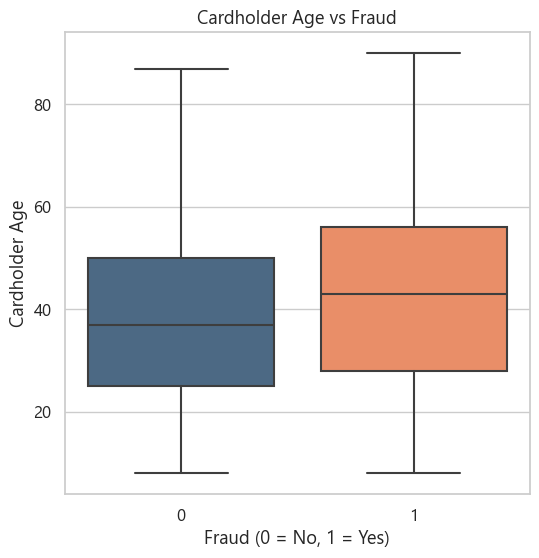

In [12]:
# visual inspection
plt.figure(figsize=(6, 6))

sns.boxplot(x="is_fraud", y="age", data=df, showfliers=False)
plt.title("Cardholder Age vs Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Cardholder Age")

plt.show()

In [17]:
# mathematical interpretation
fraud_age = df[df["is_fraud"] == 1]["age"]
nonfraud_age = df[df["is_fraud"] == 0]["age"]

# hypotheses
print("**Hypothesis Test for Cradholder Age vs Fraud**\n")
print("Null Hypothesis (H_0): The mean cardholder age is the same for fraudulent and non-fraudulent transactions.")
print("Alternative Hypothesis (H_A): The mean cardholder age for fraudulent transactions is greater than that for non-fraudulent transactions.\n")

# get means
print(f"Mean Age for Fraud: {fraud_age.mean():2f}")
print(f"Mean Age for Non-Fraud: {nonfraud_age.mean():2f}")

# two sample t-test assuming unequal variance
t_stat, p_value_two_sided = stats.ttest_ind(fraud_age, nonfraud_age, equal_var=False)
p_value_one_sided = p_value_two_sided / 2
print(f"\nt-statistic: {t_stat:.4f}")
print(f"One-sided p-value: {p_value_one_sided:.6f}")

# Cohen's d because large sample size
pooled_sd = np.sqrt(((fraud_age.var() + nonfraud_age.var()) / 2))
cohen_d = (fraud_age.mean() - nonfraud_age.mean()) / pooled_sd
print(f"Cohen's d: {cohen_d:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value_one_sided < alpha and t_stat > 0:
    print(f"\nSince p-value ({p_value_one_sided:.6f}) < {alpha}, reject the null hypothesis.")
    print("The mean age for fraudulent transactions is statistically significantly older than that for non-fraudulent transactions.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= {alpha}, we fail to reject the null hypothesis.")
    
print(f"Cohen's d of {cohen_d:.4f} indicates a small to medium effect. This suggests that fraudulent transactions tend to have slightly older cardholders, but the effect is moderate.")

**Hypothesis Test for Cradholder Age vs Fraud**

Null Hypothesis (H_0): The mean cardholder age is the same for fraudulent and non-fraudulent transactions.
Alternative Hypothesis (H_A): The mean cardholder age for fraudulent transactions is greater than that for non-fraudulent transactions.

Mean Age for Fraud: 43.614891
Mean Age for Non-Fraud: 38.807613

t-statistic: 34.9527
One-sided p-value: 0.000000
Cohen's d: 0.2624
Alpha: 0.01

Since p-value (0.000000) < 0.01, reject the null hypothesis.
The mean age for fraudulent transactions is statistically significantly older than that for non-fraudulent transactions.
Cohen's d of 0.2624 indicates a small to medium effect. This suggests that fraudulent transactions tend to have slightly older cardholders, but the effect is moderate.


**Answer**: Fraudulent transactions are more likely to involve cardholders of older ages. The t-test showed a statistically significant difference in the mean age for fraudulent (46.56 years) vs. non-fraudulent transactions (41.43 years), with a t-statistic of 38.92, a p-value < 0.000001, and a moderate effect size (Cohen’s d = 0.3028).

**Note**: Due to the large sample size, the statistical tests have very high power so we get p-values that are too small for Python to represent properly.

## References
- https://seaborn.pydata.org/tutorial/aesthetics.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind
- https://stackoverflow.com/a/52680007